# import libraries

In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib ipywidgets


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3.exe -m pip install --upgrade pip


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import ipywidgets as widgets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings("ignore")

# import dataset

In [3]:
df = pd.read_excel("Credit Risk Dataset.xlsx")

In [4]:
df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [5]:
df.tail()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
32576,CUST_32577,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,...,49.2827,-123.1207,Part-time,36,0.109434,15721.464516,0.406065,11,0.892039,1
32577,CUST_32578,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,...,53.4808,-2.2426,Full-time,60,0.146875,29674.399348,0.394162,6,0.191486,0
32578,CUST_32579,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,...,53.4808,-2.2426,Unemployed,24,0.460526,21098.865051,0.738143,11,0.678980,3
32579,CUST_32580,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,...,37.7749,-122.4194,Self-employed,36,0.100000,26361.525753,0.275744,3,0.223460,1
32580,CUST_32581,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,...,46.8139,-71.2080,Full-time,60,0.154167,9397.997205,0.377929,4,0.429304,1


In [6]:
print(f"Number of columns: {len(df.columns)}")

Number of columns: 29


In [7]:
df.shape

(32581, 29)

In [8]:
df.dtypes

client_ID                      object
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
gender                         object
marital_status                 object
education_level                object
country                        object
state                          object
city                           object
city_latitude                 float64
city_longitude                float64
employment_type                object
loan_term_months                int64
loan_to_income_ratio          float64
other_debt                    float64
debt_to_income_ratio          float64
open_account

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,1.440000e+02
person_income,32581.0,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6.000000e+06
person_emp_length,31686.0,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,1.230000e+02
loan_amnt,32581.0,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,3.500000e+04
loan_int_rate,29465.0,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,2.322000e+01
loan_status,32581.0,0.218164,0.413006,0.000000,0.000000,0.000000,0.000000,1.000000e+00
loan_percent_income,32581.0,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,8.300000e-01
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,3.000000e+01
city_latitude,32581.0,45.407613,7.644809,29.760400,40.712800,46.813900,51.507400,5.595330e+01
city_longitude,32581.0,-63.805473,46.615580,-123.365600,-96.797000,-75.697200,-3.943600,-1.278000e-01


In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

loan_int_rate        9.563856
person_emp_length    2.747000
dtype: float64


<Axes: >

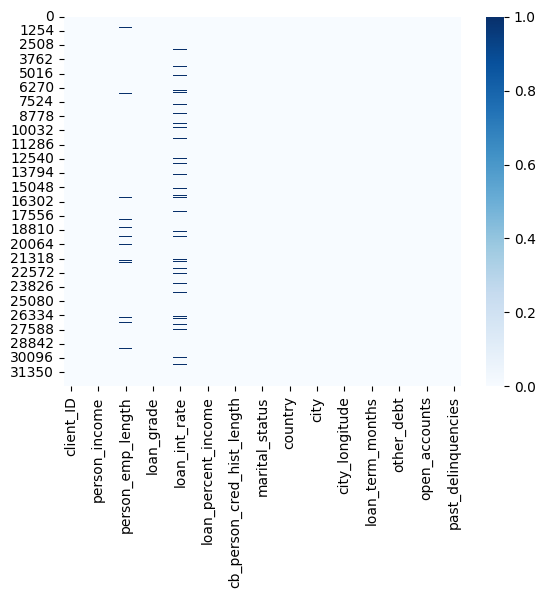

In [12]:
sns.heatmap(df.isnull(), cmap ="Blues")

Text(0.5, 1.0, 'Correlation Heatmap')

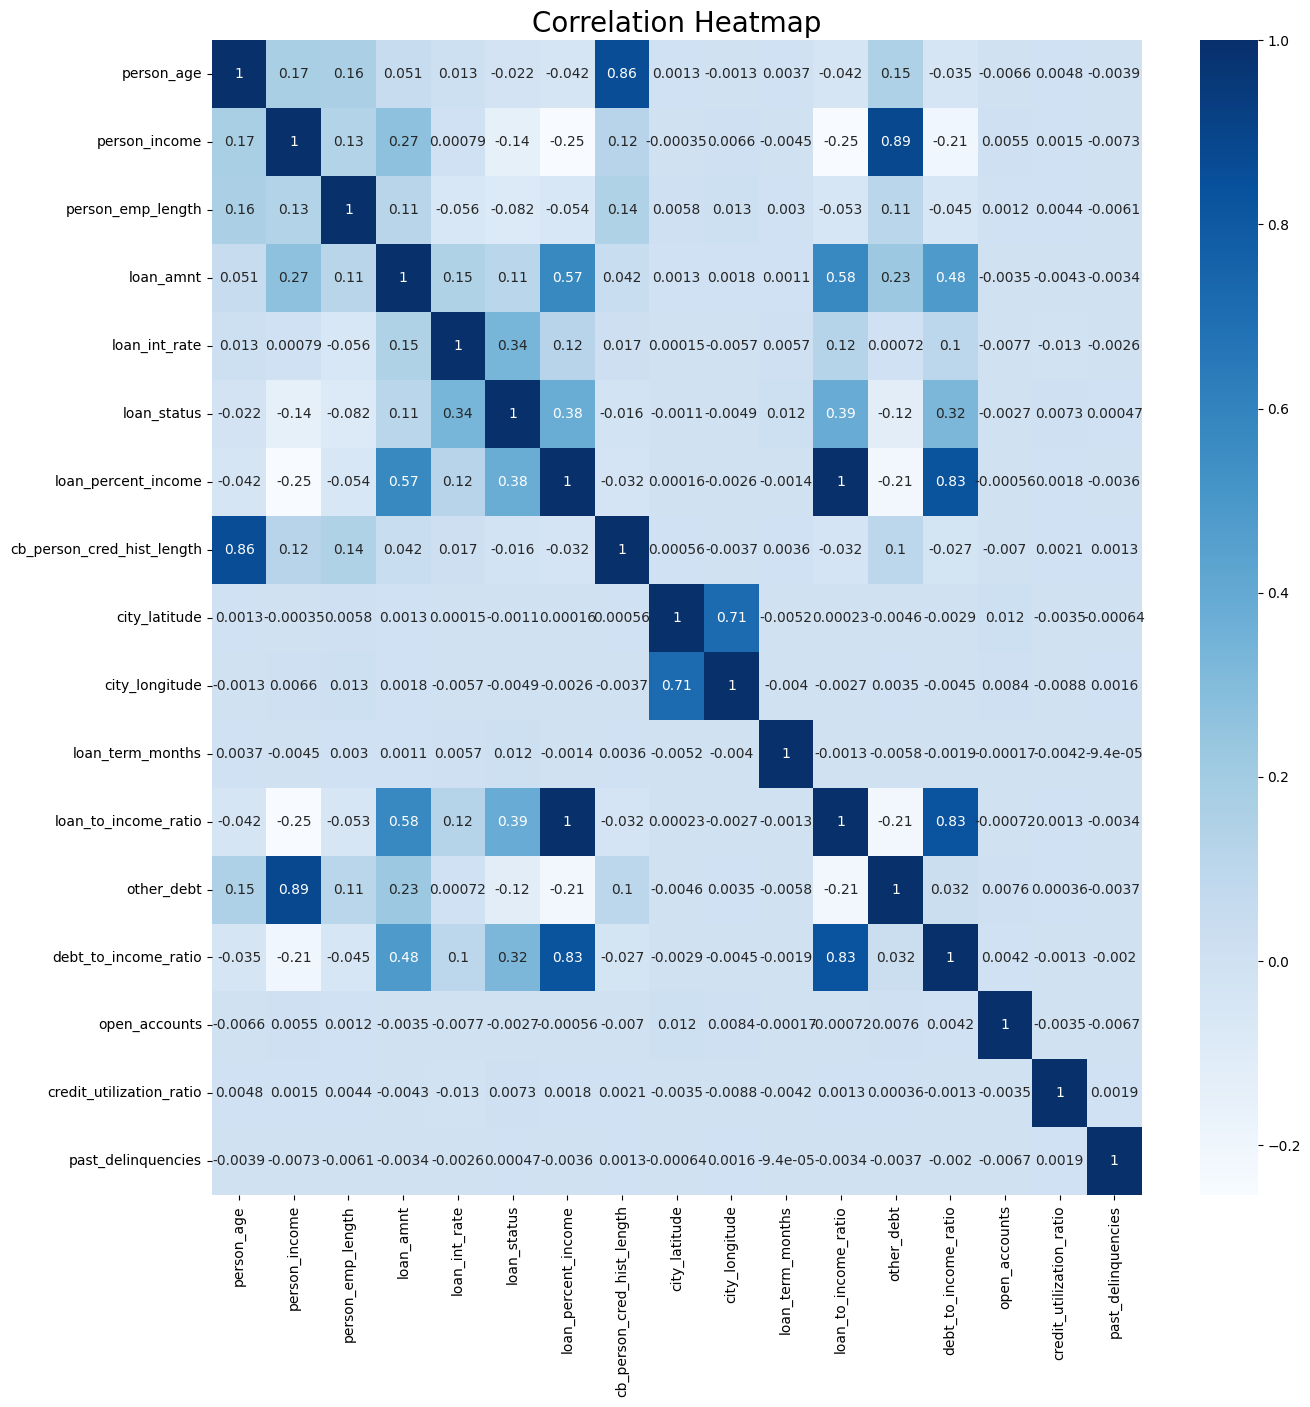

In [13]:
cor = df.select_dtypes(include='number').corr()
plt.figure(figsize=(15,15))
sns.heatmap(cor, annot=True, cmap="Blues")
plt.title('Correlation Heatmap', fontsize=20)

In [14]:

df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'] \
                        .transform(lambda x: x.fillna(x.median()))


df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())


print(df.isnull().sum().sum()) 

0


<Axes: >

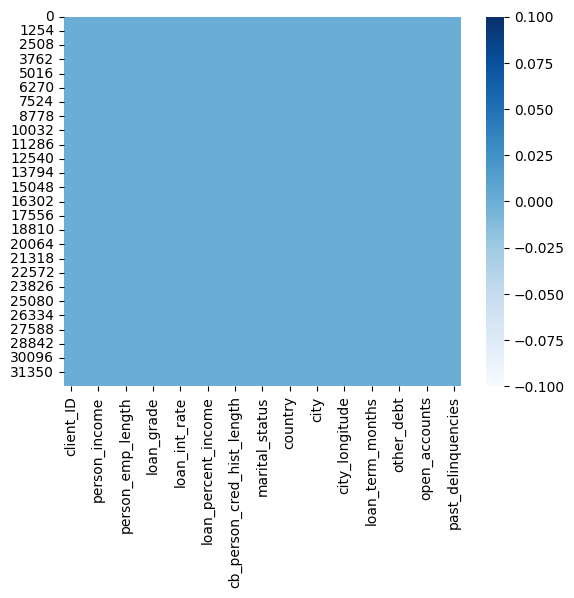

In [15]:
sns.heatmap(df.isnull(), cmap ="Blues")

In [16]:
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

Categorical columns:
['client_ID', 'person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'gender', 'marital_status', 'education_level', 'country', 'state', 'city', 'employment_type']


# data visualization

In [23]:
df_viz = df.copy()

BLUE, RED = '#2196F3', '#EF5350'
NAVY      = '#0D47A1'

ALL_CAT = ['person_home_ownership','loan_intent','loan_grade',
           'gender','marital_status','education_level',
           'country','employment_type','cb_person_default_on_file']

ALL_NUM = ['person_age','person_income','person_emp_length',
           'loan_amnt','loan_int_rate','loan_percent_income',
           'cb_person_cred_hist_length','loan_term_months',
           'loan_to_income_ratio','debt_to_income_ratio',
           'other_debt','credit_utilization_ratio',
           'open_accounts','past_delinquencies']

cat_options = [c for c in ALL_CAT if c in df_viz.columns]
num_options = [c for c in ALL_NUM if c in df_viz.columns]

dd1 = widgets.Dropdown(options=cat_options, description='Category:')
out1 = widgets.Output()

def plot_w1(col):
    with out1:
        clear_output(wait=True)
        rate = df_viz.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
        counts = df_viz[col].value_counts()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Default Analysis by [{col}]', fontsize=14, fontweight='bold')

        bars = axes[0].bar(rate.index, rate.values, color=RED, edgecolor='white', width=0.6)
        axes[0].axhline(df_viz['loan_status'].mean()*100, color=NAVY,
                        linestyle='--', linewidth=1.5, label=f'Avg: {df_viz["loan_status"].mean()*100:.1f}%')
        axes[0].set_ylabel('Default Rate (%)')
        axes[0].set_title('Default Rate by Category')
        axes[0].legend()
        for b, v in zip(bars, rate.values):
            axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                         f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
        axes[0].tick_params(axis='x', rotation=30)

        axes[1].pie(counts.values, labels=counts.index,
                    autopct='%1.1f%%', startangle=90,
                    colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts))))
        axes[1].set_title('Borrower Distribution')

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot_w1, {'col': dd1})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Widget 1 - Default Rate by Categorical</h3>'),
    dd1, out1
]))

dd2  = widgets.Dropdown(options=num_options, description='Variable:')
out2 = widgets.Output()

def plot_w2(col):
    with out2:
        clear_output(wait=True)
        g0 = df_viz[df_viz['loan_status']==0][col].dropna()
        g1 = df_viz[df_viz['loan_status']==1][col].dropna()

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'[{col}] Analysis by Default Status', fontsize=14, fontweight='bold')

        axes[0].hist(g0, bins=35, alpha=0.6, color=BLUE, label='Non-Default', density=True)
        axes[0].hist(g1, bins=35, alpha=0.6, color=RED,  label='Default',     density=True)
        axes[0].set_title('Distribution')
        axes[0].legend()

        bp = axes[1].boxplot([g0, g1], patch_artist=True,
                              tick_labels=['Non-Default','Default'])
        bp['boxes'][0].set_facecolor(BLUE)
        bp['boxes'][1].set_facecolor(RED)
        axes[1].set_title('Boxplot')

        df_viz['_q'] = pd.qcut(df_viz[col], q=4, labels=['Q1','Q2','Q3','Q4'], duplicates='drop')
        q_rate = df_viz.groupby('_q', observed=True)['loan_status'].mean() * 100
        axes[2].pie(q_rate.values, labels=[f'{i}\n{v:.1f}%' for i,v in zip(q_rate.index, q_rate.values)],
                    colors=[BLUE, '#64B5F6', '#EF9A9A', RED], startangle=90,
                    wedgeprops=dict(edgecolor='white'))
        axes[2].set_title('Default Rate by Quartile')
        df_viz.drop(columns=['_q'], inplace=True)

        stats = f"Non-Default  mean={g0.mean():.2f}  median={g0.median():.2f}\n" \
                f"Default      mean={g1.mean():.2f}  median={g1.median():.2f}"
        fig.text(0.5, -0.02, stats, ha='center', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='#E3F2FD'))

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot_w2, {'col': dd2})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Widget 2 - Numerical Analysis</h3>'),
    dd2, out2
]))

x_dd  = widgets.Dropdown(options=num_options, value=num_options[3], description='X-Axis:')
y_dd  = widgets.Dropdown(options=num_options, value=num_options[4], description='Y-Axis:')
out3  = widgets.Output()

def plot_w3(x_col, y_col):
    with out3:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{x_col} vs {y_col}', fontsize=14, fontweight='bold')

        colors = df_viz['loan_status'].map({0: BLUE, 1: RED})
        axes[0].scatter(df_viz[x_col], df_viz[y_col], c=colors, alpha=0.25, s=8)
        axes[0].set_xlabel(x_col); axes[0].set_ylabel(y_col)
        p0 = mpatches.Patch(color=BLUE, label='Non-Default')
        p1 = mpatches.Patch(color=RED,  label='Default')
        axes[0].legend(handles=[p0, p1])
        axes[0].set_title('Scatter')

        vc = df_viz['loan_status'].value_counts()
        axes[1].pie(vc.values, labels=['Non-Default','Default'],
                    autopct='%1.1f%%', colors=[BLUE, RED],
                    explode=(0, 0.05), startangle=90,
                    wedgeprops=dict(edgecolor='white'))
        axes[1].set_title('Overall Default Rate')

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot_w3, {'x_col': x_dd, 'y_col': y_dd})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Widget 3 - Scatter Plot</h3>'),
    widgets.HBox([x_dd, y_dd]), out3
]))

metric_dd = widgets.Dropdown(
    options=['default_rate','avg_loan_amnt','avg_loan_int_rate','avg_loan_to_income_ratio'],
    description='Metric:'
)
out4 = widgets.Output()

def plot_w4(metric):
    with out4:
        clear_output(wait=True)
        col_map = {
            'default_rate':           ('loan_status',         'mean',  'Default Rate (%)', 100),
            'avg_loan_amnt':          ('loan_amnt',           'mean',  'Avg Loan Amount',   1),
            'avg_loan_int_rate':      ('loan_int_rate',       'mean',  'Avg Interest Rate (%)', 1),
            'avg_loan_to_income_ratio':('loan_to_income_ratio','mean', 'Avg Loan-to-Income', 1),
        }
        src_col, agg, ylabel, mult = col_map[metric]
        if src_col not in df_viz.columns or 'country' not in df_viz.columns:
            print("Required columns not found!"); return

        data = df_viz.groupby('country')[src_col].mean() * mult
        data = data.sort_values(ascending=False)
        counts_c = df_viz['country'].value_counts()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Country Analysis - {ylabel}', fontsize=14, fontweight='bold')

        bars = axes[0].bar(data.index, data.values, color=NAVY, edgecolor='white', width=0.5)
        axes[0].set_ylabel(ylabel)
        axes[0].set_title(ylabel)
        for b, v in zip(bars, data.values):
            axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                         f'{v:.2f}', ha='center', fontsize=10, fontweight='bold', color='white'
                         if v > data.max()*0.5 else NAVY)
        axes[0].tick_params(axis='x', rotation=20)

        axes[1].pie(counts_c.values, labels=counts_c.index,
                    autopct='%1.1f%%', startangle=90,
                    colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts_c))),
                    wedgeprops=dict(edgecolor='white'))
        axes[1].set_title('Borrower Distribution by Country')

        plt.tight_layout()
        plt.show()

widgets.interactive_output(plot_w4, {'metric': metric_dd})
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#0D47A1">Widget 4 - Country Analysis</h3>'),
    metric_dd, out4
]))

# feature engineering

In [24]:
class NovaRiskFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, drop_geo_coords=True):
        self.drop_geo_coords = drop_geo_coords
        self.emp_length_median_ = None
        self.int_rate_medians_ = {}
        
    def fit(self, X, y=None):
        self.emp_length_median_ = X['person_emp_length'].median()
        self.int_rate_medians_ = X.groupby('loan_grade')['loan_int_rate'].median().to_dict()
        return self

    def transform(self, X):
        X_new = X.copy()
        
        X_new['person_emp_length'] = X_new['person_emp_length'].fillna(self.emp_length_median_)
        
        global_int_median = np.median(list(self.int_rate_medians_.values()))
        X_new['loan_int_rate'] = X_new.apply(
            lambda row: self.int_rate_medians_.get(row['loan_grade'], global_int_median) 
            if pd.isna(row['loan_int_rate']) else row['loan_int_rate'], 
            axis=1
        )

        X_new['severe_default_history'] = np.where(
            (X_new['past_delinquencies'] > 0) | (X_new['cb_person_default_on_file'] == 'Y'), 1, 0
        )
        
        X_new['vulnerable_borrower'] = np.where(
            (X_new['debt_to_income_ratio'] > 0.4) & (X_new['person_home_ownership'] == 'RENT'), 1, 0
        )
        
        X_new['est_monthly_payment'] = (X_new['loan_amnt'] * (1 + (X_new['loan_int_rate']/100))) / X_new['loan_term_months']
        
        X_new['monthly_payment_to_income'] = X_new['est_monthly_payment'] / (X_new['person_income'] / 12)
        
        X_new['stability_index'] = X_new['person_emp_length'] * X_new['cb_person_cred_hist_length']

        grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
        X_new['loan_grade_encoded'] = X_new['loan_grade'].map(grade_mapping)
        
        X_new['cb_person_default_on_file_encoded'] = X_new['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
        
        cols_to_drop = ['client_ID']
        
        if self.drop_geo_coords:
            cols_to_drop.extend(['city_latitude', 'city_longitude'])
            
        cols_to_drop.extend(['loan_grade', 'cb_person_default_on_file'])
        
        X_new.drop(columns=[c for c in cols_to_drop if c in X_new.columns], inplace=True)
        
        return X_new

In [27]:
engineer = NovaRiskFeatureEngineer(drop_geo_coords=True)
df_features = engineer.fit_transform(df)

print(f"Number of columns: {len(df_features.columns)}\n")
for col in df_features.columns:
    print(f"- {col}")

Number of columns: 31

- person_age
- person_income
- person_home_ownership
- person_emp_length
- loan_intent
- loan_amnt
- loan_int_rate
- loan_status
- loan_percent_income
- cb_person_cred_hist_length
- gender
- marital_status
- education_level
- country
- state
- city
- employment_type
- loan_term_months
- loan_to_income_ratio
- other_debt
- debt_to_income_ratio
- open_accounts
- credit_utilization_ratio
- past_delinquencies
- severe_default_history
- vulnerable_borrower
- est_monthly_payment
- monthly_payment_to_income
- stability_index
- loan_grade_encoded
- cb_person_default_on_file_encoded


In [29]:
df["loan_status"]

0        1
1        0
2        1
3        1
4        1
        ..
32576    0
32577    0
32578    1
32579    0
32580    0
Name: loan_status, Length: 32581, dtype: int64

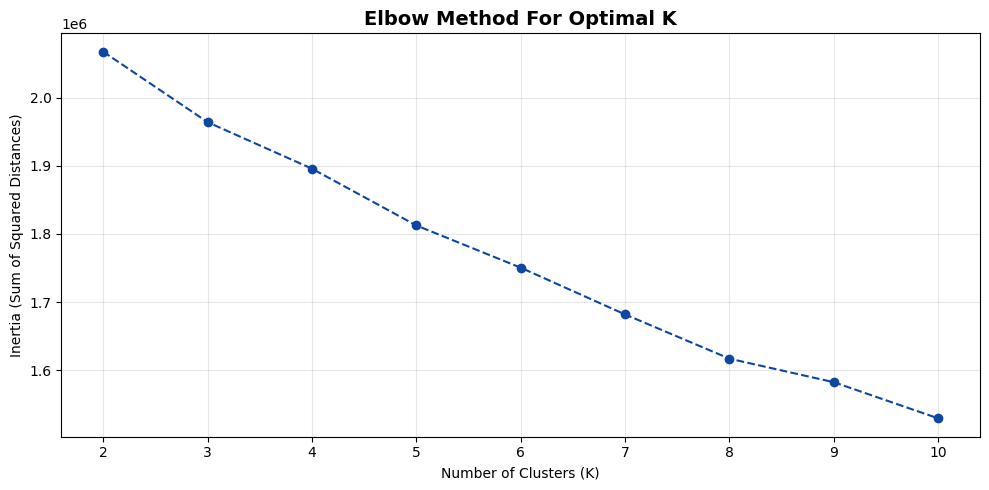

In [34]:
cluster_df = df_features.copy()
if 'loan_status' in cluster_df.columns:
    cluster_df = cluster_df.drop(columns=['loan_status'])

cat_cols = cluster_df.select_dtypes(include=['object']).columns
cluster_df = pd.get_dummies(cluster_df, columns=cat_cols, drop_first=True)

# 2. Scale the Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# 3. Elbow Method to find optimal K
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#0D47A1')
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

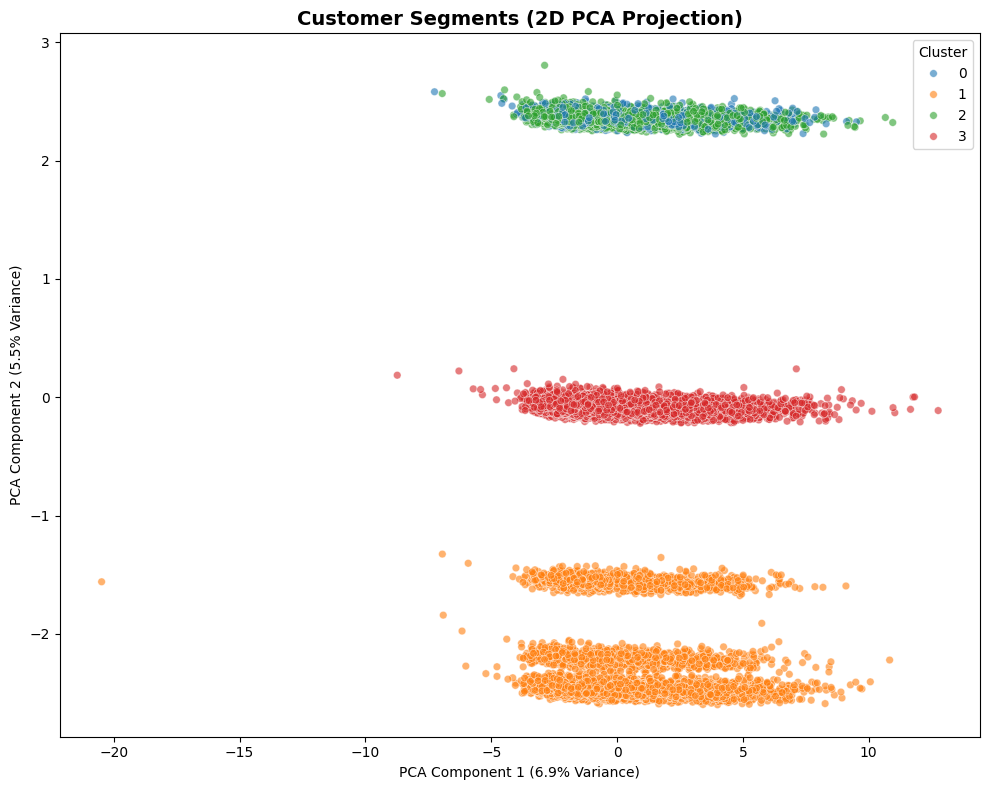

In [31]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

df_features['Cluster'] = cluster_labels
cluster_df['Cluster'] = cluster_labels

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=pca_features, columns=['PCA_Component_1', 'PCA_Component_2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA_Component_1', 
    y='PCA_Component_2',
    hue='Cluster',
    palette='tab10',
    data=pca_df,
    alpha=0.6,
    s=30
)
plt.title('Customer Segments (2D PCA Projection)', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [33]:
profiling_cols = [
    'person_income', 'loan_amnt', 'loan_int_rate', 
    'person_age', 'debt_to_income_ratio', 'vulnerable_borrower',
    'stability_index', 'est_monthly_payment'
]

if 'loan_status' in df_features.columns:
    profiling_cols.append('loan_status')

cluster_profile = df_features.groupby('Cluster')[profiling_cols].mean().round(3)
cluster_counts = df_features['Cluster'].value_counts().sort_index()
cluster_profile.insert(0, 'Customer_Count', cluster_counts)

print(cluster_profile.T)

Cluster                       0          1          2          3
Customer_Count         3654.000  10852.000   7290.000  10785.000
person_income         66854.309  66040.643  66031.077  65874.769
loan_amnt              9709.818   9552.737   9505.991   9641.785
loan_int_rate            10.957     11.009     11.010     11.041
person_age               27.696     27.747     27.747     27.727
debt_to_income_ratio      0.345      0.346      0.344      0.346
vulnerable_borrower       0.178      0.171      0.172      0.174
stability_index          30.846     30.359     30.167     29.377
est_monthly_payment     355.375    345.718    348.844    352.408
loan_status               0.218      0.219      0.217      0.219


# model constructing

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5095
           1       0.53      0.78      0.63      1422

    accuracy                           0.80      6517
   macro avg       0.73      0.79      0.75      6517
weighted avg       0.84      0.80      0.82      6517

ROC-AUC Score: 0.8764



ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

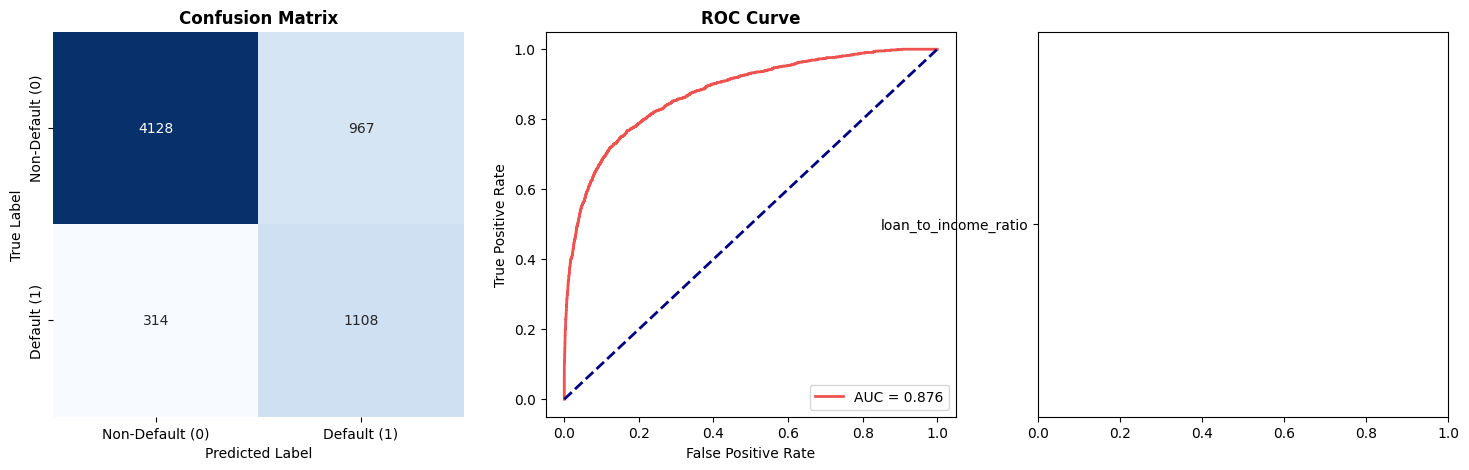

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

X = df_features.drop(columns=['loan_status', 'Cluster'], errors='ignore')
y = df_features['loan_status']

cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])
axes[0].set_yticklabels(['Non-Default (0)', 'Default (1)'])

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#EF5350', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
top_features = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(10)

sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=top_features, 
    palette=top_features['Coefficient'].apply(lambda x: '#EF5350' if x > 0 else '#2196F3'),
    ax=axes[2]
)
axes[2].set_title('Top 10 Feature Importances', fontweight='bold')
axes[2].set_xlabel('Coefficient Value (Impact on Default Probability)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()